# Lab 3: KNN, Bayes Classifier and Decision Trees

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes') # to remove extra junk
    )
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})

df["category"] = df["target"].map(
    dict(enumerate(newsgroups.target_names))
)

### 1. Loading and exploring data
- (a) How many instances (examples) and variables are in the dataset?

In [54]:
print(df.shape[0])

18846


There are 18846 instances in this dataset, but it has no variables. The dataset is just composed of raw strings just a single entry of text

- (b) (3 points) How many and which classes does the dataset define? What is their share in the
data?

In [55]:
print('Number of classes:', df['category'].nunique())
print('Classes:')
print(df['category'].unique())
print('-------')

classSummary = pd.DataFrame({
    'count': df['category'].value_counts(),
    'share in %': df['category'].value_counts(normalize=True).mul(100).round(2)
})

print(classSummary)

Number of classes: 20
Classes:
<StringArray>
[        'rec.sport.hockey', 'comp.sys.ibm.pc.hardware',
    'talk.politics.mideast',    'comp.sys.mac.hardware',
          'sci.electronics',       'talk.religion.misc',
                'sci.crypt',                  'sci.med',
              'alt.atheism',          'rec.motorcycles',
                'rec.autos',           'comp.windows.x',
            'comp.graphics',                'sci.space',
       'talk.politics.guns',             'misc.forsale',
       'rec.sport.baseball',       'talk.politics.misc',
  'comp.os.ms-windows.misc',   'soc.religion.christian']
Length: 20, dtype: str
-------
                          count  share in %
category                                   
rec.sport.hockey            999        5.30
soc.religion.christian      997        5.29
rec.motorcycles             996        5.28
rec.sport.baseball          994        5.27
sci.crypt                   991        5.26
sci.med                     990        5.25
re

- (c) (5 points) Make a plot showing the class distribution in the dataset

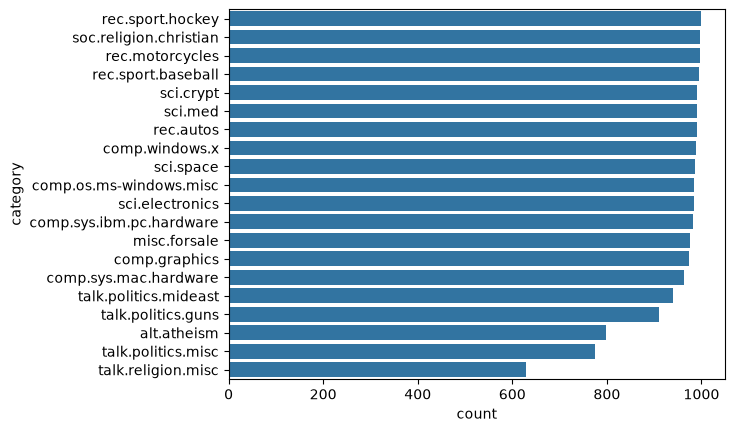

In [59]:
sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index
    )
plt.show()

- (d) (5 points) Look at a few of the samples. Is there anything in the examples that might cause a classifier to overfit to the training data? How can you fix this? Change the code above accordingly! (You may want to check the documentation of fetch 20newsgroups.)
The header, footer and quotes of every post could cause a classifier to overfit the training data, removing them with the following:
```python
remove=('headers', 'footers', 'quotes')
```
when fetching the dataset. Headers may contain usernames, emails and org names associated with a class, footers may contain repeated signatures and qoutes may repeat text from the message

### 2. Splitting the data into training and test data 
- (a) (5 points) Split the data into a training and test set using 20% of the data for testing, esnuring
class distributions between the training and test data remain the same.

In [63]:
from sklearn.model_selection import train_test_split

dfTrain, dfTest = train_test_split(
    df,
    test_size=0.2,
    random_state=200,
    stratify=df['target']
)
dfTrain = dfTrain.reset_index(drop=True)
dfTest = dfTest.reset_index(drop=True)


- (b) (5 points) Make a plot to check that the class distributions in the test set is the same as for the distribution in the whole data set.

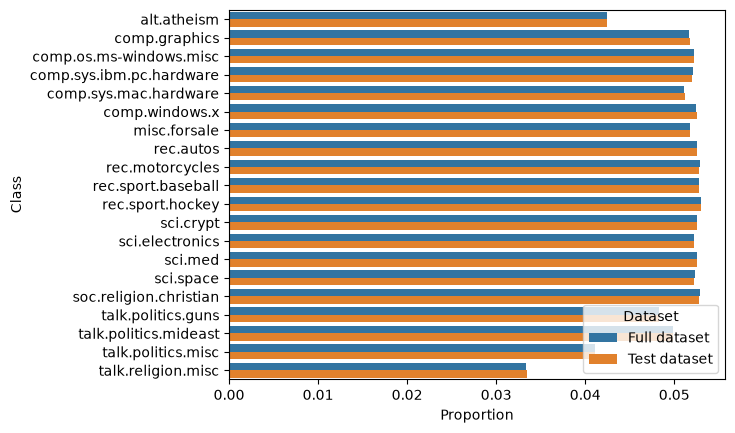

In [76]:
dist = pd.DataFrame({
    "Full dataset": df['category'].value_counts(normalize=True),
    "Test dataset": dfTest['category'].value_counts(normalize=True)
}).reset_index()

dist = dist.rename(columns={'category': 'Class'})
dist = dist.melt(
    id_vars='Class',
    var_name='Dataset',
    value_name='Proportion'
)

sns.barplot(
    data=dist,
    y='Class',
    x='Proportion',
    hue='Dataset'
)
plt.show()

### 3. Feature Engineering / Extraction
The data we are dealing with is basically unstructured text. In order to train a classifier we need to create features from the data to be used as the attributes of the samples. Scikit-learn provides us with some simple feature engineering / extraction for text. To start with we can use a simple Bag
of Words representation, where each text is represented by a vector of integers, each one counting the occurrences of specific words in the text.

In [82]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_features = vectorizer.fit_transform(dfTrain['text'])

- (a) (5 points) How many attributes do we get from this feature engineering/extraction? Do you think this is a good number? Why (not)?


In [ ]:
print('number of attributes', X_features.shape[1])

numb of attr 113584


The CountVectorizer created 113584 attributes. Each attribute is a unique word found in the training documents. This is a pretty large number because there are many different words. This creates a high dimensional and sparse dataset which increases cost of computing and includes unhelpful words.

- (b) (5 points) Change the parameters of CountVectorizer to exclude words appearing in more than
half the instances and words appearing in less than 0.1% of the instances. How many attributes
do you get after that change?

In [83]:
vectorizerFiltered = CountVectorizer(
    max_df=0.5,
    min_df=0.001
)
X_featuresFiltered = vectorizerFiltered.fit_transform(dfTrain['text'])
print('number of attributes', X_featuresFiltered.shape[1])

number of attributes 8865


- (c) (5 points) The output of CountVectorizer is not always very informative. Words that appear often (like ’it’, ’is’, ’has’, etc) tend to have higher values, but contain little information about the topic because they appear in many different documents. We could try weight words higher if
they appear in fewer documents. TfidfTransformer does exactly that. Apply a TfidfTransformer to the output of the CountVectorizer!

In [86]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_featuresFiltered)
print(X_tfidf.shape)

(15076, 8865)


### 4. Training a model and evaluating with cross-validation
- (a) (5 points) Use scikit-learn’s KNeighborsClassifier to learn a K-nearest Neighbor Classifier from the training data.

In [100]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier(
    n_neighbors=5
)
knc.fit(
    X_tfidf,
    dfTrain['target']
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](20,)","[ 0, 1, 2,...,17,18,19]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


- (b) (5 points) How many neighbors does the classifier use? It uses 5 neighbors as specified by the 'n_neighbors=5' parameter

- (c) (5 points) Use 5-fold cross-validation to estimate the models accuracy on both training and validation set. (It might be easiest to use sklearn.model selection.cross validate() for this).

In [101]:
from sklearn.model_selection import cross_validate

result = cross_validate(
    knc,
    X_tfidf,
    dfTrain['target'],
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

print('Training accuracy: ', result['train_score'])
print('Training accuracy mean:', result['train_score'].mean())
print('Validation accuracy: ', result['test_score'])
print('Validation accuracy mean: ', result['test_score'].mean())

Training accuracy:  [0.36658375 0.36464638 0.36050079 0.3780781  0.369704  ]
Training accuracy mean: 0.3679026048212905
Validation accuracy:  [0.10842175 0.11144279 0.10912106 0.10912106 0.11343284]
Validation accuracy mean:  0.11030789905468237


- (d) (5 points) What do the numbers tell you about overfitting/underfitting of the model? <br>
Seeing that our model has 36.8% training accuracy and 11% validation accuracy i would say or model is underfitting.

- (e) (5 points) Replace the KNN classifier with a Naive-Bayes classifier (MultinomialNB) and measure its accuracy using cross-validation. How well does this model perform in comparision?

In [102]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()

result = cross_validate(
    clf,
    X_tfidf,
    dfTrain['target'],
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

print('Training accuracy: ', result['train_score'])
print('Training accuracy mean:', result['train_score'].mean())
print('Validation accuracy: ', result['test_score'])
print('Validation accuracy mean: ', result['test_score'].mean())

Training accuracy:  [0.80447761 0.80300141 0.79951911 0.80349888 0.80805903]
Training accuracy mean: 0.8037112093128587
Validation accuracy:  [0.69396552 0.68490879 0.69684909 0.68557214 0.68524046]
Validation accuracy mean:  0.6893071996340139


Using Naive-Bayes classifier we see our accuracy for, Training jump fromm 36.8% to 80% and our Validation from 11% to 69%, this model would be a good fit compared to our KNN classifier and this model performs better.
### 5. Pipeline and Hyperparameter-Tuning (Total points: 35)
 Both preprocessing steps, as well as the classifier have hyper-parameters that could be tuned to get a better model. This is easiest to do, if we put all of these steps together in a pipeline that can be treated as an estimator without having to run each individual step when testing different parameter values.

- (a) (5 points) Pick a classifier (KNN Classifier, Naive-Bayes, decision tree, or something else that you tried before). Put all the preprocessing steps and the classifier into a pipeline


In [99]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('classifier',MultinomialNB())
])

params = {
    'vectorizer__max_df': [0.5, 0.75, 1.0],
    'vectorizer__min_df': [0.0005, 0.001, 0.005],
    'classifier__alpha': [0.1, 1.0, 10.0]
}

search = GridSearchCV(
    pipeline,
    params,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

search.fit(dfTrain['text'], dfTrain['target'])

print(search.best_params_)
print(search.best_score_)


{'classifier__alpha': 0.1, 'vectorizer__max_df': 0.5, 'vectorizer__min_df': 0.0005}
0.7361371304397553


- (b) (10 points) Select 1 or 2 hyperparameters for each step in the pipeline that you find most important for the task. Select around 3 reasonable values for each hyper-parameter (2 in case of non-numeric hyperparameters that only have two options) and setup a search for the best combination of hyper-parameter values in the pipeline. This can be done for example using GridSearchCV or RandomizedSearchCV (see the user guide on grid search). Note: When setting this up, think about the potential run-time of the search. For each tested parameter combination, the search will do cross-validation. Think about how many combinations of values you want to test and how long it takes run the pipeline once before running this, otherwise you
might be surprised about the run-time. <br>
We selected max_df and min_df because they control what words our model uses, ignore those that are in 50%, 75% and 100%, also those that appear less than 0.05%, 0.1% or 0.5%.
We also chose alpha because it helps control smoothing in Naive Bayes

In [ ]:
params = {
    'vectorizer__max_df': [0.5, 0.75, 1.0],
    'vectorizer__min_df': [0.0005, 0.001, 0.005],
    'classifier__alpha': [0.1, 1.0, 10.0]
}

- (c) (5 points) Report on the results. Which parameter combination is best? How good is it? Does that model still suffer from overfitting?

In [110]:
print('Training scores: ', search.cv_results_['mean_train_score'])
print('Validation scores: ', search.cv_results_['mean_test_score'])
print("Best parameters:", search.best_params_)
print("Best validation accuracy:", search.best_score_)

Training scores:  [0.90632462 0.88753651 0.78333112 0.90542915 0.88715511 0.7837125
 0.90521358 0.88705561 0.78367934 0.81480504 0.8042087  0.7343957
 0.8060494  0.79702843 0.73185857 0.80394341 0.79512141 0.73106259
 0.65544569 0.65557835 0.61631065 0.59274667 0.60067318 0.58105591
 0.57470471 0.58465432 0.57162039]
Validation scores:  [0.73613713 0.7192889  0.63644158 0.73540749 0.71922259 0.63564556
 0.73514215 0.71875826 0.63584452 0.6918944  0.68731717 0.62708887
 0.68479699 0.6807504  0.62423673 0.68240891 0.67909209 0.62350702
 0.57541763 0.57886676 0.54908409 0.51386276 0.52613346 0.51790871
 0.49608599 0.51001533 0.50908682]
Best parameters: {'classifier__alpha': 0.1, 'vectorizer__max_df': 0.5, 'vectorizer__min_df': 0.0005}
Best validation accuracy: 0.7361371304397553


The best parameter combination is max_df=0.5, min_df=0.0005, alpha=0.1 which got a validation score of 73.6% with a training accuracy of 90.6%. A 17% gap suggests that the model is overfitting.

- (d) (10 points) Analyze the results of the search in more detail. Which of the tuned parameters seems to have the most influence on performance of the model (reducing overfitting or underfitting)? Which parameters are independent/dependent on each other? (the independent ones could have been tuned separately)

In [111]:
results_df = pd.DataFrame(search.cv_results_)

# Group by each parameter and compute mean validation accuracy
print("Effect of max_df:")
print(results_df.groupby('param_vectorizer__max_df')['mean_test_score'].mean())

print("\nEffect of min_df:")
print(results_df.groupby('param_vectorizer__min_df')['mean_test_score'].mean())

print("\nEffect of alpha:")
print(results_df.groupby('param_classifier__alpha')['mean_test_score'].mean())

Effect of max_df:
param_vectorizer__max_df
0.50    0.644615
0.75    0.626441
1.00    0.621105
Name: mean_test_score, dtype: float64

Effect of min_df:
param_vectorizer__min_df
0.0005    0.650128
0.0010    0.646605
0.0050    0.595427
Name: mean_test_score, dtype: float64

Effect of alpha:
param_classifier__alpha
0.1     0.696876
1.0     0.664566
10.0    0.530718
Name: mean_test_score, dtype: float64


Alpha has the largest impact on model performance. Validation accuracy ranges from 53.1% to 69.7% which is a 16.6% gap. While max_df only varies by 2.4$ and min_df by 5.5%. This shows that controlling Naive Bayes smoothing is critical for this model. <br>
max_df and min_df are independent. They both control filtering but can be tuned separately, but alpha is somewhat dependent on the feature set.

- (e) (5 points) Try out other preprocessing steps, other hyper-parameters and other models (e.g., TfidfVectorizer or MultinomialNB). What is the best model you can come up with?

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier

pipeline_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.5, min_df=0.001)),
    ('classifier', MultinomialNB())
])

params_tfidf = {
    'tfidf__max_df': [0.5, 0.75, 1.0],
    'tfidf__min_df': [0.001, 0.005],
    'classifier__alpha': [0.1, 1.0, 10.0]
}

search_tfidf = GridSearchCV(
    pipeline_tfidf, 
    params_tfidf,
    cv=5,
    scoring='accuracy',
    return_train_score=True
    )

search_tfidf.fit(
    dfTrain['text'],
    dfTrain['target']
)

print("TfidfVectorizer + MultinomialNB:")
print(f"Best validation accuracy: {search_tfidf.best_score_:.4f}")
print(f"Best parameters: {search_tfidf.best_params_}\n")

pipeline_dt = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.5, min_df=0.001)),
    ('classifier', DecisionTreeClassifier(random_state=200))
])

params_dt = {
    'tfidf__max_df': [0.5, 0.75],
    'tfidf__min_df': [0.001, 0.005],
    'classifier__max_depth': [10, 20, 30]
}

search_dt = GridSearchCV(pipeline_dt, params_dt, cv=5, scoring='accuracy', return_train_score=True)
search_dt.fit(dfTrain['text'], dfTrain['target'])

print("TfidfVectorizer + DecisionTree:")
print(f"Best validation accuracy: {search_dt.best_score_:.4f}")
print(f"Best parameters: {search_dt.best_params_}")

TfidfVectorizer + MultinomialNB:
Best validation accuracy: 0.7193
Best parameters: {'classifier__alpha': 0.1, 'tfidf__max_df': 0.5, 'tfidf__min_df': 0.001}

TfidfVectorizer + DecisionTree:
Best validation accuracy: 0.3204
Best parameters: {'classifier__max_depth': 30, 'tfidf__max_df': 0.5, 'tfidf__min_df': 0.001}


We experimented with 2 alternative models
1. TfidfVectorizer + MultinominalNB: Best validation accuracy of 71.93% with params: max_df=0.5, min_df=0.001, alpha=0.1
2. TfidfVectorizer + DecisionTree: Best validation accuracy of 32.04% with params: max_df=0.5, min_df=0.001, max_depth=30 <br>
The original CountVectorizer+TfidfTransformer_MultinominalNB pipeline remains the best model with 73.6% validation accuracy, outperforming the alternative TfidfVectorizer by ~1.7% and the DecisionTree by ~41.6%.